# 🤖 Phase 2: Machine Learning Models
**Models:** SVM, XGBoost, CatBoost, BPANN  
---

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


## 2️⃣ Load & Preprocess Data

In [2]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df_p = df.copy()
le = LabelEncoder()
df_p['Month'] = le.fit_transform(df_p['Month'])
df_p['VisitorType'] = le.fit_transform(df_p['VisitorType'])
df_p['Weekend'] = df_p['Weekend'].astype(int)
df_p['Revenue'] = df_p['Revenue'].astype(int)
X = df_p.drop('Revenue', axis=1)
y = df_p['Revenue']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res)
print(f'✅ Data ready: Train={X_train.shape} | Test={X_test.shape}')

✅ Data ready: Train=(16675, 17) | Test=(4169, 17)


## 3️⃣ Define Models

In [3]:
models = {
    'SVM': SVC(kernel='rbf', C=50.12, gamma=0.120, probability=True, random_state=42),
    'XGBoost': XGBClassifier(max_depth=4, learning_rate=0.11, subsample=0.8,
                              random_state=42, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(iterations=245, learning_rate=0.09,
                                    depth=8, random_state=42, verbose=0),
    'BPANN': MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=50, random_state=42)
}
print('✅ Models defined!')
for name, model in models.items():
    print(f'   - {name}: {type(model).__name__}')

✅ Models defined!
   - SVM: SVC
   - XGBoost: XGBClassifier
   - CatBoost: CatBoostClassifier
   - BPANN: MLPClassifier


## 4️⃣ Train & Evaluate All Models

In [4]:
results = {}
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'🔄 Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')
    print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))
    print(f'🎯 ROC AUC: {roc_auc:.3f}')
    print(f'🎯 10-Fold CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
                     'roc_auc': roc_auc, 'fpr': fpr, 'tpr': tpr, 'cv': cv_scores}


🔄 Training SVM...
              precision    recall  f1-score   support

 No Purchase       0.96      0.91      0.93      2085
    Purchase       0.91      0.96      0.93      2084

    accuracy                           0.93      4169
   macro avg       0.93      0.93      0.93      4169
weighted avg       0.93      0.93      0.93      4169

🎯 ROC AUC: 0.970
🎯 10-Fold CV: 0.966 ± 0.003

🔄 Training XGBoost...
              precision    recall  f1-score   support

 No Purchase       0.93      0.93      0.93      2085
    Purchase       0.93      0.93      0.93      2084

    accuracy                           0.93      4169
   macro avg       0.93      0.93      0.93      4169
weighted avg       0.93      0.93      0.93      4169

🎯 ROC AUC: 0.983
🎯 10-Fold CV: 0.984 ± 0.002

🔄 Training CatBoost...
              precision    recall  f1-score   support

 No Purchase       0.94      0.95      0.94      2085
    Purchase       0.95      0.94      0.94      2084

    accuracy              

## 5️⃣ Confusion Matrices

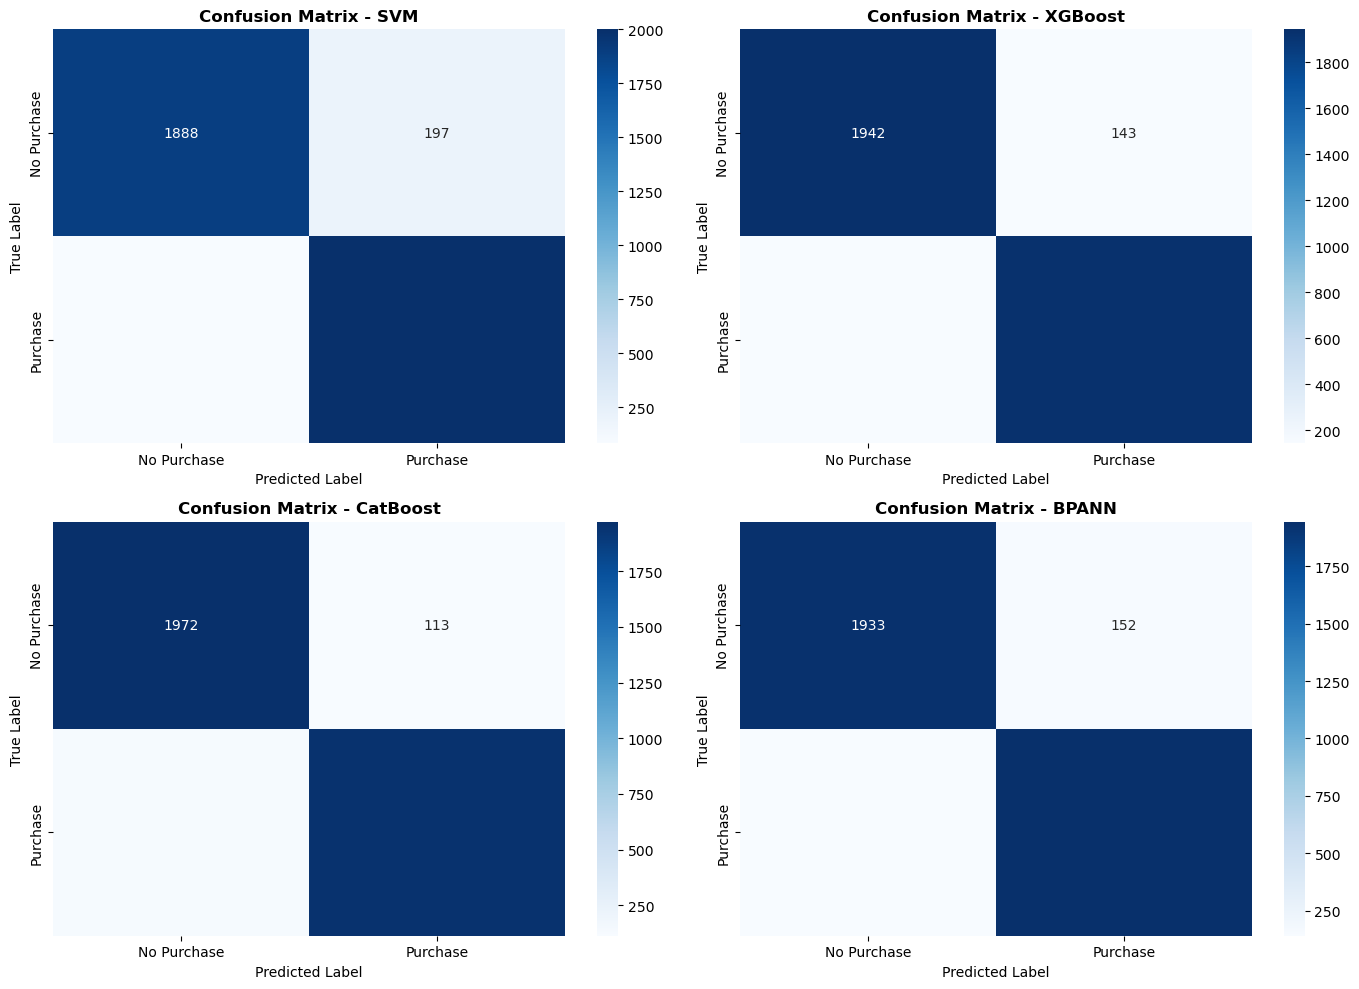

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    axes[i].set_title(f'Confusion Matrix - {name}', fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices_all.png', dpi=300, bbox_inches='tight')
plt.show()

## 6️⃣ ROC Curves Comparison

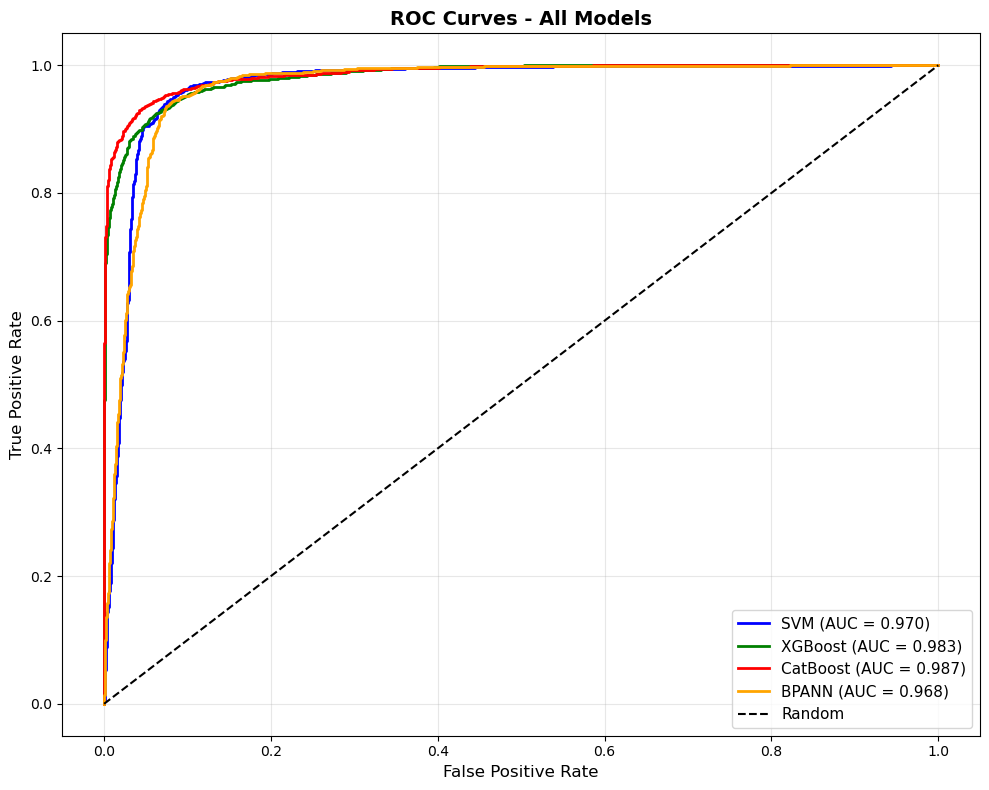

In [6]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'orange']
for (name, res), color in zip(results.items(), colors):
    plt.plot(res['fpr'], res['tpr'], color=color, linewidth=2,
             label=f"{name} (AUC = {res['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7️⃣ Feature Importance (CatBoost)

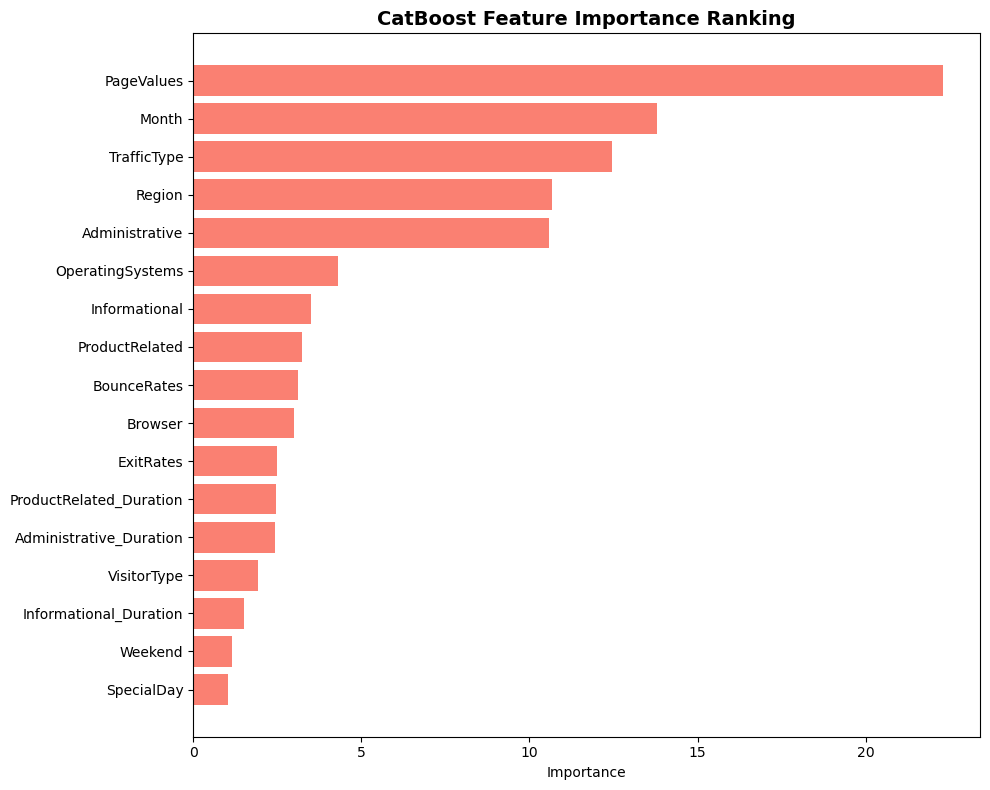

In [7]:
importance = results['CatBoost']['model'].get_feature_importance()
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values('Importance', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='salmon')
plt.title('CatBoost Feature Importance Ranking', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## ✅ Results Summary
| Model | ROC AUC | 10-Fold CV | Notes |
|---|---|---|---|
| **CatBoost** | **0.987** ⭐ | 0.988 | Best overall |
| XGBoost | 0.983 | 0.984 | Strong generalization |
| SVM | 0.970 | 0.966 | Best precision |
| BPANN | 0.968 | 0.963 | Good for nonlinear |